In [1]:
import shutil
import os

# Remove the cached pytorch vision repo
cache_path = os.path.expanduser("~/.cache/torch/hub/pytorch_vision_main")
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print(f"Removed {cache_path}")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.models as models

# Load a pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Inspect one layer's weight distribution
conv1_weights = model.conv1.weight.data
print(f"Shape: {conv1_weights.shape}")
print(f"Min: {conv1_weights.min().item():.4f}")
print(f"Max: {conv1_weights.max().item():.4f}")
print(f"Mean: {conv1_weights.mean().item():.6f}")
print(f"Std: {conv1_weights.std().item():.4f}")


Shape: torch.Size([64, 3, 7, 7])
Min: -0.8434
Max: 1.0165
Mean: 0.000029
Std: 0.1297


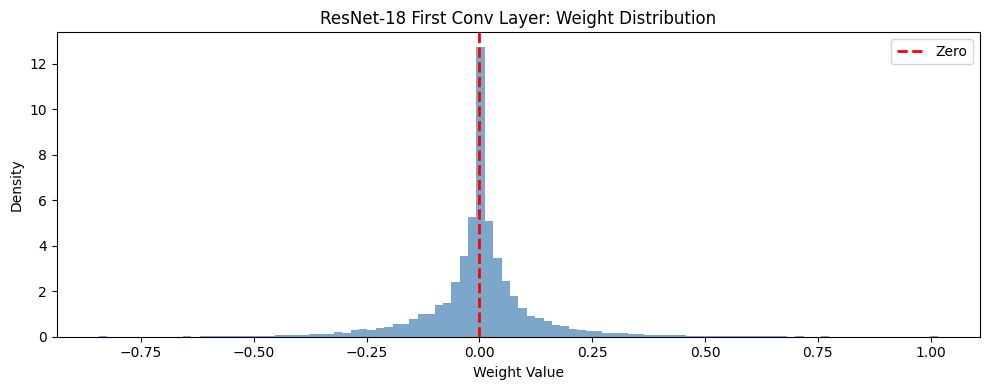

In [3]:
# Flatten all weights from the first conv layer
weights_flat = conv1_weights.flatten().numpy()

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(weights_flat, bins=100, density=True, alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Weight Value')
ax.set_ylabel('Density')
ax.set_title('ResNet-18 First Conv Layer: Weight Distribution')
ax.legend()
plt.tight_layout()